# mcp Basics

# keys import

In [22]:
import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")

# Model Loading

In [23]:
import os
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch  # updated at 1.0

#llm
##################
llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}},
)
response = llm.invoke("What is the color of the sky answer in one word?")
print(response.content)

# llm
####################
# Initialize the model (you can use models like gemini-2.5-flash or gemini-pro)
llmg = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=GOOGLE_API_KEY)
response = llmg.invoke("What is the color of the sky answer in one word?")
print(response.content)



blue
Blue


# for runing asynic in notebook

In [2]:
import sys
import asyncio

# =============================================================================
# Windows + Jupyter + MCP Fix: Async Subprocess Support
# =============================================================================
# Problem: Windows SelectorEventLoop doesn't support subprocess creation
# Solution: Replace the running event loop with ProactorEventLoop
# =============================================================================

if sys.platform == "win32":
    # Step 1: Set ProactorEventLoop policy for subprocess support
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

    # Step 2: Close and replace Jupyter's existing event loop
    # Jupyter creates a SelectorEventLoop before our code runs, so we must replace it
    try:
        loop = asyncio.get_running_loop()
        # We can't replace a running loop, but we can verify it's the right type
        if not isinstance(loop, asyncio.ProactorEventLoop):
            print("WARNING: Event loop is already running and is not ProactorEventLoop")
            print("You may need to restart the kernel for full compatibility")
    except RuntimeError:
        # No loop is running, create a new ProactorEventLoop
        loop = asyncio.ProactorEventLoop()
        asyncio.set_event_loop(loop)

    # Step 3: Fix stderr for subprocess compatibility
    # Jupyter's sys.stderr doesn't have fileno(), which breaks subprocess.Popen
    if "ipykernel" in sys.modules:
        import io
        # Replace Jupyter's stderr with the original stderr or a null stream
        if hasattr(sys, '__stderr__') and sys.__stderr__ is not None:
            sys.stderr = sys.__stderr__
        else:
            # Fallback: use devnull if __stderr__ is not available
            sys.stderr = open('nul', 'w')  # 'nul' is Windows equivalent of /dev/null

print(f"Event loop type: {type(asyncio.get_event_loop()).__name__}")
print(f"Event loop policy: {type(asyncio.get_event_loop_policy()).__name__}")
print("Windows MCP subprocess support configured successfully!")

You may need to restart the kernel for full compatibility
Event loop type: _WindowsSelectorEventLoop
Event loop policy: WindowsProactorEventLoopPolicy
Windows MCP subprocess support configured successfully!


# Set up MCP Server object (Optional)

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "mcp_server": {
            "transport": "stdio",
            "command" : "python",
            "args": ["resources/2.1_mcp_server.py"]
        }
    }
)

# set up MCP client object

In [3]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "my_server": {
            "url": "http://localhost:8000/mcp",
            "transport": "streamable_http",
        }
    }
)

In [47]:
# get tools
tools = await client.get_tools()
print(tools)

tools = await client.get_tools()
print([t.name for t in tools])

resources = await client.get_resources("my_server")
print(resources)


prompt = await client.get_prompt("my_server", "prompt")
print(prompt)


[StructuredTool(name='search_web', description='Search the web for information', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'search_webArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x0000025F438EA5C0>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000025F46A63BA0>)]
['search_web']
[Blob 2608230498384]
[HumanMessage(content='\n    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.\n\n    You can use the following tools/resources to answer user questions:\n    - search_web: Search the web for information\n    - github_file: Access the langchain-ai repo files\n\n    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I\'m sorry, I can only answer questions about LangChain, LangGraph and LangSmith."\n\n    You may try m

## tools

In [5]:
tools = await client.get_tools()

search_tool = next(
    t for t in tools
    if t.name == "search_web"
)

result = await search_tool.ainvoke(
    {"query": "latest LangGraph features"}
)

print(result)

[{'type': 'text', 'text': '{\n  "query": "latest LangGraph features",\n  "follow_up_questions": null,\n  "answer": null,\n  "images": [],\n  "results": [\n    {\n      "url": "https://medium.com/@romerorico.hugo/langgraph-1-0-released-no-breaking-changes-all-the-hard-won-lessons-8939d500ca7c",\n      "title": "LangGraph 1.0: Changes Guide for AI Engineers - Medium",\n      "content": "LangGraph 1.0 released in October 2025. Discover production-ready features: durable execution, streaming, human oversight & memory",\n      "score": 0.74697095,\n      "raw_content": null\n    },\n    {\n      "url": "https://www.reddit.com/r/LangChain/comments/1njlqfq/new_langgraph_and_langchain_v1",\n      "title": "New langgraph and langchain v1 - Reddit",\n      "content": "The LangChain team dropped new features last week. Here\'s a quick look at what\'s new: New create_agent Primitive: Easily create agents with",\n      "score": 0.7018975,\n      "raw_content": null\n    },\n    {\n      "url": "htt

In [6]:
result

[{'type': 'text',
  'text': '{\n  "query": "latest LangGraph features",\n  "follow_up_questions": null,\n  "answer": null,\n  "images": [],\n  "results": [\n    {\n      "url": "https://medium.com/@romerorico.hugo/langgraph-1-0-released-no-breaking-changes-all-the-hard-won-lessons-8939d500ca7c",\n      "title": "LangGraph 1.0: Changes Guide for AI Engineers - Medium",\n      "content": "LangGraph 1.0 released in October 2025. Discover production-ready features: durable execution, streaming, human oversight & memory",\n      "score": 0.74697095,\n      "raw_content": null\n    },\n    {\n      "url": "https://www.reddit.com/r/LangChain/comments/1njlqfq/new_langgraph_and_langchain_v1",\n      "title": "New langgraph and langchain v1 - Reddit",\n      "content": "The LangChain team dropped new features last week. Here\'s a quick look at what\'s new: New create_agent Primitive: Easily create agents with",\n      "score": 0.7018975,\n      "raw_content": null\n    },\n    {\n      "url": "h

In [7]:
tools

[StructuredTool(name='search_web', description='Search the web for information', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'search_webArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x0000025F438EA5C0>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000025F43BE0680>)]

In [8]:
# get tools
tools = await client.get_tools()

In [9]:
tools

[StructuredTool(name='search_web', description='Search the web for information', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'search_webArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x0000025F438EA5C0>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000025F43C68E00>)]

## resources

In [19]:
tools = await client.get_tools()
print([t.name for t in tools])

resources = await client.get_resources("my_server")
print(resources)


['search_web']
[Blob 2608182321200]


In [20]:
resources

[Blob 2608182321200]

In [21]:
# 2. Loop through the list and extract the hidden data
for blob in resources:
    # Use .data to get the string content directly
    text_content = blob.data 
    
    print("--- Found Resource Data ---")
    print(text_content)

--- Found Resource Data ---
# LangChain MCP Adapters

This library provides a lightweight wrapper that makes [Anthropic Model Context Protocol (MCP)](https://modelcontextprotocol.io/introduction) tools compatible with [LangChain](https://github.com/langchain-ai/langchain) and [LangGraph](https://github.com/langchain-ai/langgraph).

![MCP](static/img/mcp.png)

> [!note]
> A JavaScript/TypeScript version of this library is also available at [langchainjs](https://github.com/langchain-ai/langchainjs/tree/main/libs/langchain-mcp-adapters/).

## Features

- 🛠️ Convert MCP tools into [LangChain tools](https://python.langchain.com/docs/concepts/tools/) that can be used with [LangGraph](https://github.com/langchain-ai/langgraph) agents
- 📦 A client implementation that allows you to connect to multiple MCP servers and load tools from them

## Installation

```bash
pip install langchain-mcp-adapters
```

## Quickstart

Here is a simple example of using the MCP tools with a LangGraph agent.

```ba

## prompt

In [15]:
prompt = await client.get_prompt("my_server", "prompt")
# await client.get_resources("my_server")

In [36]:
prompt

[HumanMessage(content='\n    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.\n\n    You can use the following tools/resources to answer user questions:\n    - search_web: Search the web for information\n    - github_file: Access the langchain-ai repo files\n\n    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I\'m sorry, I can only answer questions about LangChain, LangGraph and LangSmith."\n\n    You may try multiple tool and resource calls to answer the user\'s question.\n\n    You may also ask clarifying questions to the user to better understand their question.\n    ', additional_kwargs={}, response_metadata={})]

In [48]:
print(prompt[0].content)


    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.

    You can use the following tools/resources to answer user questions:
    - search_web: Search the web for information
    - github_file: Access the langchain-ai repo files

    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I'm sorry, I can only answer questions about LangChain, LangGraph and LangSmith."

    You may try multiple tool and resource calls to answer the user's question.

    You may also ask clarifying questions to the user to better understand their question.
    


# langchain Agent only

In [28]:
from langchain.agents import create_agent

llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}},
)

# 3. Create the agent by passing the 'llm' variable into the model parameter
agent = create_agent(
    model=llm,          # Pass the llm object here instead of a "string"
    tools=tools,        # The tool list loaded from your server
    system_prompt=prompt[0].content  # The text rules from the server prompt
)

# 4. Ask the agent a question
response = await agent.ainvoke(
    {"messages": "What is LangGraph and what tools do you have answer in two lines only"}
)
print(response)

{'messages': [HumanMessage(content='What is LangGraph and what tools do you have answer in two lines only', additional_kwargs={}, response_metadata={}, id='174ddadd-0032-436e-ba44-c2f20186388f'), AIMessage(content='LangGraph is a library for building stateful, graph‑based agents in the LangChain ecosystem.  \nI can use the search_web and github_file tools to retrieve information.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-11T15:34:37.670633799Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2391835590, 'load_duration': None, 'prompt_eval_count': 419, 'prompt_eval_duration': None, 'eval_count': 182, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019eb75a-7e00-78f3-b8f8-cdd3d2f88241-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 419, 'output_tokens': 182, 'total_tokens': 601})]}


In [34]:
print(response['messages'][1].content)

LangGraph is a library for building stateful, graph‑based agents in the LangChain ecosystem.  
I can use the search_web and github_file tools to retrieve information.


# langraph logic React agent inside graph

In [40]:
from langgraph.prebuilt import create_react_agent

In [41]:
# 3. Create the LangGraph workflow agent
# It takes your LLM model object, the tools list, and the system prompt instructions
agent_graph = create_react_agent(
    model=llm,
    tools=tools,
    prompt=prompt[0].content  # Passes the strict topic rules to the AI
)

# 4. Invoke the LangGraph agent workflow
# LangGraph expects a dictionary with a list of message objects inside
inputs = {
    "messages": [
        {"role": "user", "content": "What is LangGraph and what tools do you have answer in two lines only"}
    ]
}

C:\Users\smrit\AppData\Local\Temp\ipykernel_8204\1512004992.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_graph = create_react_agent(


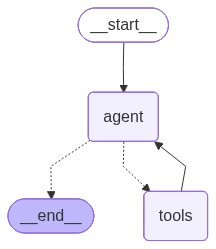

In [42]:
# Show
from IPython.display import Image, display
display(Image(agent_graph.get_graph(xray=True).draw_mermaid_png()))



In [43]:
# Run the graph asynchronously
response = await agent_graph.ainvoke(inputs)

# LangGraph updates the message list state. The final answer is the last message.
final_answer = response["messages"][-1]
print("\n--- Agent Response ---")
print(final_answer.content)


--- Agent Response ---
LangGraph is a framework for building stateful, multi‑agent applications using graphs of LLMs and tools.  
I have access to the `search_web` and `github_file` tools to retrieve information.


# importing mcp from mpc.o

In [54]:
from langchain_mcp_adapters.client import  MultiServerMCPClient

kiwiClient = MultiServerMCPClient(
    {
        "travel_server":{
            "transport": "streamable_http",
            "url": "https://mcp.kiwi.com"
        }
    }
)

tools = await kiwiClient.get_tools()

print(tools)

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [55]:
# 2. Download the tool objects from the server
tools = await kiwiClient.get_tools()

In [56]:
tools

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [75]:
from langchain_mcp_adapters.client import  MultiServerMCPClient

kiwiClient = MultiServerMCPClient(
    {
        "travel_server":{
            "transport": "streamable_http",
            "url": "https://mcp.kiwi.com"
        }
    }
)

tools = await kiwiClient.get_tools()

print(tools)

# 2. Download the tool objects from the server
tools = await kiwiClient.get_tools()

if not tools:
    print("No tools returned from the server.")
    

# 3. Print names to see what Kiwi offers (e.g., 'search_flights')
print("Available Tools:")
for t in tools:
    print(f"- {t.name}: {t.description}")

# 4. Trigger the first tool manually with a sample query dictionary
# (Adjust the arguments below to match what your printed tool expects!)
sample_tool = tools[0]
print(f"\n🚀 Executing tool: '{sample_tool.name}'...")

sample_arguments = {
        "flyFrom": "PRG",
        "flyTo": "BCN",
        "departureDate": "2026-08-25"
    }


try:
    # Use .ainvoke() to trigger the tool with your argument variables
    result = await sample_tool.ainvoke(sample_arguments)
    print("\n--- Tool Response Received ---")
    print(result)
except Exception as e:
    print(f"Error running tool: {e}")

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [63]:
result

[{'type': 'text',
  'text': '{\n  "query": "latest LangGraph features",\n  "follow_up_questions": null,\n  "answer": null,\n  "images": [],\n  "results": [\n    {\n      "url": "https://medium.com/@romerorico.hugo/langgraph-1-0-released-no-breaking-changes-all-the-hard-won-lessons-8939d500ca7c",\n      "title": "LangGraph 1.0: Changes Guide for AI Engineers - Medium",\n      "content": "LangGraph 1.0 released in October 2025. Discover production-ready features: durable execution, streaming, human oversight & memory",\n      "score": 0.74697095,\n      "raw_content": null\n    },\n    {\n      "url": "https://www.reddit.com/r/LangChain/comments/1njlqfq/new_langgraph_and_langchain_v1",\n      "title": "New langgraph and langchain v1 - Reddit",\n      "content": "The LangChain team dropped new features last week. Here\'s a quick look at what\'s new: New create_agent Primitive: Easily create agents with",\n      "score": 0.7018975,\n      "raw_content": null\n    },\n    {\n      "url": "h

In [72]:
print(sample_tool.get_input_schema().model_json_schema())

{'$defs': {'ToolCall': {'description': 'Represents an AI\'s request to call a tool.\n\nExample:\n    ```python\n    {"name": "foo", "args": {"a": 1}, "id": "123"}\n    ```\n\n    This represents a request to call the tool named `\'foo\'` with arguments\n    `{"a": 1}` and an identifier of `\'123\'`.\n\n!!! note "Factory function"\n\n    `tool_call` may also be used as a factory to create a `ToolCall`. Benefits\n    include:\n\n    * Required arguments strictly validated at creation time', 'properties': {'name': {'title': 'Name', 'type': 'string'}, 'args': {'additionalProperties': True, 'title': 'Args', 'type': 'object'}, 'id': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'title': 'Id'}, 'type': {'const': 'tool_call', 'title': 'Type', 'type': 'string'}}, 'required': ['name', 'args', 'id'], 'title': 'ToolCall', 'type': 'object'}}, 'anyOf': [{'type': 'string'}, {'additionalProperties': True, 'type': 'object'}, {'$ref': '#/$defs/ToolCall'}], 'title': 'search-flight_input'}


In [74]:
import json

print(
    json.dumps(
        sample_tool.get_input_schema().model_json_schema(),
        indent=2
    )
)

{
  "$defs": {
    "ToolCall": {
      "description": "Represents an AI's request to call a tool.\n\nExample:\n    ```python\n    {\"name\": \"foo\", \"args\": {\"a\": 1}, \"id\": \"123\"}\n    ```\n\n    This represents a request to call the tool named `'foo'` with arguments\n    `{\"a\": 1}` and an identifier of `'123'`.\n\n!!! note \"Factory function\"\n\n    `tool_call` may also be used as a factory to create a `ToolCall`. Benefits\n    include:\n\n    * Required arguments strictly validated at creation time",
      "properties": {
        "name": {
          "title": "Name",
          "type": "string"
        },
        "args": {
          "additionalProperties": true,
          "title": "Args",
          "type": "object"
        },
        "id": {
          "anyOf": [
            {
              "type": "string"
            },
            {
              "type": "null"
            }
          ],
          "title": "Id"
        },
        "type": {
          "const": "tool_call",


In [76]:
sample_tool.get_input_schema().model_json_schema()

{'$defs': {'ToolCall': {'description': 'Represents an AI\'s request to call a tool.\n\nExample:\n    ```python\n    {"name": "foo", "args": {"a": 1}, "id": "123"}\n    ```\n\n    This represents a request to call the tool named `\'foo\'` with arguments\n    `{"a": 1}` and an identifier of `\'123\'`.\n\n!!! note "Factory function"\n\n    `tool_call` may also be used as a factory to create a `ToolCall`. Benefits\n    include:\n\n    * Required arguments strictly validated at creation time',
   'properties': {'name': {'title': 'Name', 'type': 'string'},
    'args': {'additionalProperties': True, 'title': 'Args', 'type': 'object'},
    'id': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'title': 'Id'},
    'type': {'const': 'tool_call', 'title': 'Type', 'type': 'string'}},
   'required': ['name', 'args', 'id'],
   'title': 'ToolCall',
   'type': 'object'}},
 'anyOf': [{'type': 'string'},
  {'additionalProperties': True, 'type': 'object'},
  {'$ref': '#/$defs/ToolCall'}],
 'title': 'sea

In [77]:
for tool in tools:
    print("=" * 80)
    print("NAME:", tool.name)
    print("DESCRIPTION:", tool.description)

NAME: search-flight
DESCRIPTION: 
# Search for a flight

## Description

Uses the Kiwi API to search for available flights between two locations on a specific date.

## How it works

The tool will:
1. Search for matching locations to resolve airport codes
2. Find available flights for the specified route and date range

## Method

Call this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.

You should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest 'totalDurationInSeconds') and the rest (those that could still be interesting).

Always display for each flight in order:
  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")
  - In the 2nd column: The departure and arrival dates & times in the local timezones, and durat

In [80]:
search_tool

StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates &

In [81]:
try:
    result = await search_tool.ainvoke(
        {
            "flyFrom": "PRG",
            "flyTo": "BCN",
            "departureDate": "2026-08-25"
        }
    )
    print(result)

except Exception as e:
    print(e)
    

MCP error -32602: MCP error -32602: Invalid arguments for tool search-flight: [
  {
    "validation": "regex",
    "code": "invalid_string",
    "message": "date must be in dd/mm/yyyy format",
    "path": [
      "departureDate"
    ]
  }
]


In [86]:
result = await search_tool.ainvoke(
    {
        "flyFrom": "DEL",
        "flyTo": "BNG",
        "departureDate": "25/08/2026"
    }
)

print(result)

[{'type': 'text', 'text': '[\n  {\n    "flyFrom": "DEL",\n    "flyTo": "BKK",\n    "cityFrom": "New Delhi",\n    "cityTo": "Bangkok",\n    "departure": {\n      "utc": "2026-08-24T18:35:00.000Z",\n      "local": "2026-08-25T00:05:00.000"\n    },\n    "arrival": {\n      "utc": "2026-08-25T03:05:00.000Z",\n      "local": "2026-08-25T10:05:00.000"\n    },\n    "totalDurationInSeconds": 30600,\n    "durationInSeconds": 30600,\n    "price": 147,\n    "deepLink": "https://on.kiwi.com/b5z8jE",\n    "currency": "EUR",\n    "layovers": [\n      {\n        "at": "SGN",\n        "city": "Ho Chi Minh City",\n        "cityCode": "SGN",\n        "arrival": {\n          "utc": "2026-08-24T23:35:00.000Z",\n          "local": "2026-08-25T06:35:00.000"\n        },\n        "departure": {\n          "utc": "2026-08-25T01:35:00.000Z",\n          "local": "2026-08-25T08:35:00.000"\n        }\n      }\n    ]\n  },\n  {\n    "flyFrom": "DEL",\n    "flyTo": "BKK",\n    "cityFrom": "New Delhi",\n    "cityTo":

In [87]:
print(result[0]['text'])

[
  {
    "flyFrom": "DEL",
    "flyTo": "BKK",
    "cityFrom": "New Delhi",
    "cityTo": "Bangkok",
    "departure": {
      "utc": "2026-08-24T18:35:00.000Z",
      "local": "2026-08-25T00:05:00.000"
    },
    "arrival": {
      "utc": "2026-08-25T03:05:00.000Z",
      "local": "2026-08-25T10:05:00.000"
    },
    "totalDurationInSeconds": 30600,
    "durationInSeconds": 30600,
    "price": 147,
    "deepLink": "https://on.kiwi.com/b5z8jE",
    "currency": "EUR",
    "layovers": [
      {
        "at": "SGN",
        "city": "Ho Chi Minh City",
        "cityCode": "SGN",
        "arrival": {
          "utc": "2026-08-24T23:35:00.000Z",
          "local": "2026-08-25T06:35:00.000"
        },
        "departure": {
          "utc": "2026-08-25T01:35:00.000Z",
          "local": "2026-08-25T08:35:00.000"
        }
      }
    ]
  },
  {
    "flyFrom": "DEL",
    "flyTo": "BKK",
    "cityFrom": "New Delhi",
    "cityTo": "Bangkok",
    "departure": {
      "utc": "2026-08-24T19:00:00.0

In [88]:
tools

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [94]:
print("NAME:", tools[0].name)
print("DESCRIPTION:", tools[0].description)

NAME: search-flight
DESCRIPTION: 
# Search for a flight

## Description

Uses the Kiwi API to search for available flights between two locations on a specific date.

## How it works

The tool will:
1. Search for matching locations to resolve airport codes
2. Find available flights for the specified route and date range

## Method

Call this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.

You should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest 'totalDurationInSeconds') and the rest (those that could still be interesting).

Always display for each flight in order:
  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")
  - In the 2nd column: The departure and arrival dates & times in the local timezones, and durat